In [1]:
# Instalar biblioteca
!pip install ucimlrepo

#**DADOS DE TREINO**

In [12]:
# ==========================================================
# TREINO DIGITS UCI
# PCA com 10 componentes
# ==========================================================

import pickle as p1
import numpy as np

from ucimlrepo import fetch_ucirepo

from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# ==========================================================
# Dataset UCI
# ==========================================================

digits = fetch_ucirepo(id=80)

# ==========================================================
# Features e targets
# ==========================================================

X = np.array(
    digits.data.features
)

y = np.array(
    digits.data.targets
).ravel()

# ==========================================================
# Número total de dados
# ==========================================================

M = len(X)

print("Número total de dados:", M)

# ==========================================================
# 2/3 treino
# ==========================================================

m = int((2 * M) / 3)

print("Número treino:", m)

# ==========================================================
# Dados treino
# ==========================================================

X_train_original = X[:m]

y_train = y[:m]

# ==========================================================
# Dados teste
# ==========================================================

X_test_original = X[m:]

y_test = y[m:]

print("Número teste:", len(X_test_original))

# ==========================================================
# PCA + Standardização
# ==========================================================

pca_pipeline = make_pipeline(
    StandardScaler(),
    PCA(n_components=10)
)

# ==========================================================
# Ajustar PCA ao treino
# ==========================================================

X_train = pca_pipeline.fit_transform(
    X_train_original
)

# ==========================================================
# Transformar teste
# ==========================================================

X_test = pca_pipeline.transform(
    X_test_original
)

print(
    "Número componentes PCA:",
    X_train.shape[1]
)

# ==========================================================
# Modelo KNN
# ==========================================================

modelo = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

# ==========================================================
# Treino
# ==========================================================

modelo.fit(
    X_train,
    y_train
)

# ==========================================================
# Accuracy
# ==========================================================

y_pred = modelo.predict(X_test)

acc = accuracy_score(
    y_test,
    y_pred
)

print(f"\nAccuracy: {(acc*100):.2f}")

# ==========================================================
# Guardar modelo
# ==========================================================

with open("KNeighborsClassifier.pkl", "wb") as f:

    p1.dump(modelo, f)

print("Modelo KNeighborsClassifier guardado.")

# ==========================================================
# Guardar PCA
# ==========================================================

with open("digits_pca.pkl", "wb") as f:

    p1.dump(pca_pipeline, f)

print("PCA guardado.")

# ==========================================================
# Guardar dados teste
# ==========================================================

dados_teste = [
    X_test,
    y_test,
    X_test_original
]

with open("digits_test.pkl", "wb") as f:

    p1.dump(dados_teste, f)

print("Dados teste guardados.")

Número total de dados: 5620
Número treino: 3746
Número teste: 1874
Número componentes PCA: 10

Accuracy: 92.96
Modelo KNeighborsClassifier guardado.
PCA guardado.
Dados teste guardados.


#**DADOS DE TESTE**

Accuracy: 92.96


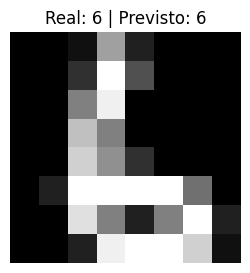

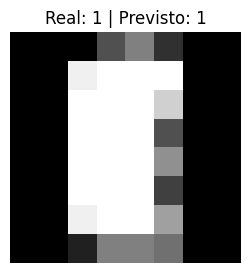

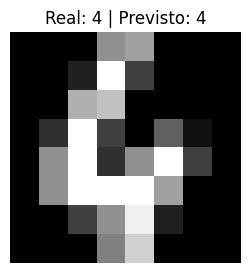

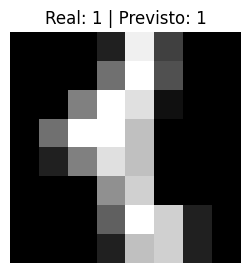

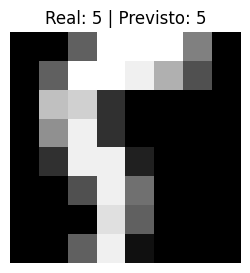

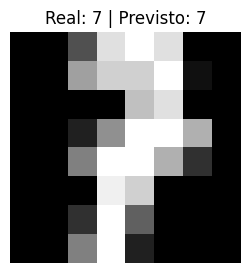

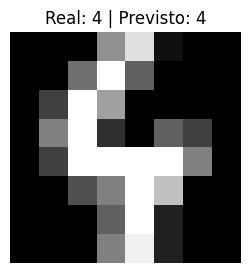

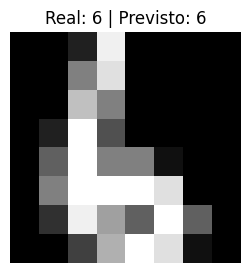

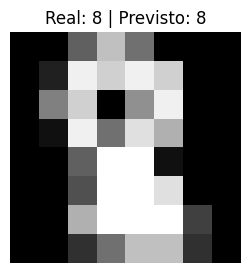

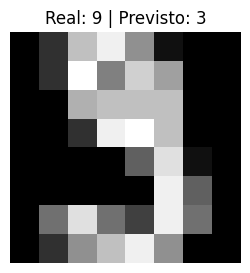

In [13]:
# ==========================================================
# TESTE DIGITS
# ==========================================================

import pickle as p1
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

# ==========================================================
# Carregar modelo
# ==========================================================

with open("KNeighborsClassifier.pkl", "rb") as f:

    modelo = p1.load(f)

# ==========================================================
# Carregar dados teste
# ==========================================================

with open("digits_test.pkl", "rb") as f:

    X_test, y_test, X_test_original = p1.load(f)

# ==========================================================
# Predições
# ==========================================================

y_pred = modelo.predict(X_test)

# ==========================================================
# Accuracy
# ==========================================================

acc = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {(acc*100):.2f}")

# ==========================================================
# Mostrar exemplos
# ==========================================================

for i in range(10):

    imagem = X_test_original[i].reshape(8,8)

    real = y_test[i]

    previsto = y_pred[i]

    plt.figure(figsize=(3,3))

    plt.imshow(
        imagem,
        cmap="gray"
    )

    plt.title(
        f"Real: {real} | Previsto: {previsto}"
    )

    plt.axis("off")

    plt.show()

#**DADOS DE PREVISÃO**

Escolha índice do dígito: 350


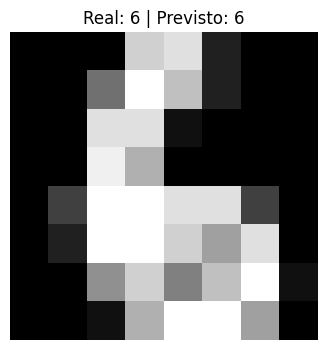


Valor previsto: 6
Valor real: 6


In [14]:
# ==========================================================
# PREDIÇÃO DIGITS
# ==========================================================

import pickle as p1
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

# ==========================================================
# Modelo
# ==========================================================

with open("KNeighborsClassifier.pkl", "rb") as f:

    modelo = p1.load(f)

# ==========================================================
# PCA
# ==========================================================

with open("digits_pca.pkl", "rb") as f:

    pca_pipeline = p1.load(f)

# ==========================================================
# Dataset
# ==========================================================

digits = fetch_ucirepo(id=80)

X = np.array(
    digits.data.features
)

y = np.array(
    digits.data.targets
).ravel()

# ==========================================================
# Escolher índice
# ==========================================================

n = int(
    input("Escolha índice do dígito: ")
)

# ==========================================================
# Imagem original
# ==========================================================

imagem = X[n].reshape(8,8)

# ==========================================================
# Aplicar PCA
# ==========================================================

x_pca = pca_pipeline.transform(
    [X[n]]
)

# ==========================================================
# Predição
# ==========================================================

pred = modelo.predict(x_pca)

# ==========================================================
# Mostrar imagem
# ==========================================================

plt.figure(figsize=(4,4))

plt.imshow(
    imagem,
    cmap="gray"
)

plt.title(
    f"Real: {y[n]} | Previsto: {pred[0]}"
)

plt.axis("off")

plt.show()

print("\nValor previsto:", pred[0])

print("Valor real:", y[n])